# Multi-Modal Neural Network for Construction Cost Prediction

This notebook builds a model combining:
- Tabular data (MLP)
- Sentinel-2 imagery (CNN)
- VIIRS imagery (CNN)

We fuse all modalities into a final regression model.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import datetime
import random
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



print("Using device:", device)

Using device: cuda


### Random handling

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Dataset handling
Loading and preparing dataset for the model

### Loading Data

In [3]:
DataPath = Path("..") / "Processed data"
ImgPath = DataPath / "processed_composite"
ModelPath = Path("..") / "Models"

#Loading all images into a dict to avoid loading them multiple times during training
img_dict = {}
for img_file in ImgPath.glob("*.pt"):
    img_dict[img_file.name] = torch.load(img_file)

full_df = pd.read_csv(DataPath / "processed_data.csv")
print(f"Full shape: {full_df.shape}")

japan_df = pd.read_csv(DataPath / "processed_japan.csv")
print(f"Japan shape: {japan_df.shape}")

philippines_df = pd.read_csv(DataPath / "processed_philippines.csv")
print(f"Philippines shape: {philippines_df.shape}")

eval_df = pd.read_csv(DataPath / "processed_eval.csv")
print(f"Eval shape: {eval_df.shape}")

full_df.head()

C:\Users\nicol\AppData\Local\Temp\ipykernel_16480\2372364685.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  img_dict[img_file.name] = torch.load(img_file)


Full shape: (1024, 20)
Japan shape: (567, 17)
Philippines shape: (457, 19)
Eval shape: (1024, 19)


,data_id,geolocation_name,quarter_label,country,deflated_gdp_usd,us_cpi,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,construction_cost_per_m2_usd,processed_imgs
0,LP81L,0,0.086957,0,0.002133,0.059541,0,1,0,1,1,0,0.496774,2,1,3,0,0,129.997420,dinagat_islands_2019-Q3.pt
1,E7EOB,1,0.913043,1,0.919424,0.973574,1,3,0,0,1,1,0.238710,2,1,1,0,3,1567.878774,29000_nara_2024-Q2.pt
2,WAOUA,2,0.173913,1,0.954862,0.085467,0,3,1,1,1,1,0.290323,2,1,1,0,5,2009.827701,05000_akita_2020-Q1.pt
3,2IZ5P,3,0.304348,0,0.000000,0.119109,1,1,1,0,1,0,0.561290,3,1,2,0,0,377.279961,cotabato_2020-Q4.pt
4,RJ5XF,4,0.086957,0,0.002133,0.059541,1,1,1,0,1,1,0.041935,2,1,2,0,1,163.905688,pampanga_2019-Q3.pt


### Dataset class
For easier access of the data for the models

In [4]:
class MultiModalDataset(Dataset):
    def __init__(self, df, numeric_cols, categorical_cols,
                 imgs_col, target_col, id_col):
        self.df = df.reset_index(drop=True)
        numeric_cols = [col for col in numeric_cols if col in df.columns]
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.imgs_col = imgs_col
        self.target_col = target_col
        self.id_col = id_col
        
    def __len__(self):
        return len(self.df)
    
    def load_imgs(self, path):
        return img_dict.get(path)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        x_num = torch.tensor(
            row[self.numeric_cols].values.astype("float32"),
            dtype=torch.float32
        )

        x_cat = torch.tensor(
            row[self.categorical_cols].values.astype("int64"),
            dtype=torch.long
        )

        imgs = self.load_imgs(row[self.imgs_col])
        img_s = imgs['sentinel']
        img_v = imgs['viirs']

        if self.target_col in self.df.keys():
            y = torch.tensor(
                float(row[self.target_col]),
                dtype=torch.float32
            )
        else:
            y = None
        
        if self.id_col in self.df.keys():
            data_id = row[self.id_col]
        else:
            data_id = None

        return {
            "numeric": x_num,
            "categorical": x_cat,
            "sentinel_img": img_s,
            "viirs_img": img_v,
            "target": y,
            "id": data_id
        }

### Possible columns in the data

In [5]:
numeric_cols = [
    'deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km',
    'access_to_airport', 'access_to_highway', 'access_to_port',
    'access_to_railway', 'country', 'landlocked', 'flood_risk_class',
    'quarter_label', 'region_economic_classification',
    'seismic_hazard_zone', 'tornadoes_wind_risk',
    'tropical_cyclone_wind_risk'
]

target_col = 'construction_cost_per_m2_usd'

categorical_cols = ['geolocation_name', 'koppen_climate_zone']

img_col = "processed_imgs"

id_col = "data_id"

### Converting Data
Converting the data to make sure the model gets the correct data type.

In [6]:
#Convert the columns to the appropriate data types
def convert_dtypes(df, numeric_cols, categorical_cols):
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    return df

full_df = convert_dtypes(full_df, numeric_cols, categorical_cols)
japan_df = convert_dtypes(japan_df, numeric_cols, categorical_cols)
philippines_df = convert_dtypes(philippines_df, numeric_cols, categorical_cols)

print(full_df[numeric_cols].dtypes)
print(full_df[categorical_cols].dtypes)

deflated_gdp_usd                   float64
us_cpi                             float64
straight_distance_to_capital_km    float64
access_to_airport                    int64
access_to_highway                    int64
access_to_port                       int64
access_to_railway                    int64
country                              int64
landlocked                           int64
flood_risk_class                     int64
quarter_label                      float64
region_economic_classification       int64
seismic_hazard_zone                  int64
tornadoes_wind_risk                  int64
tropical_cyclone_wind_risk           int64
dtype: object
geolocation_name       category
koppen_climate_zone    category
dtype: object


## Model Definition

### Tabular Model (MLP with Embeddings)

In [7]:
class TabularModel(nn.Module):
    def __init__(self, num_numeric, cat_dims, emb_dims, dropout):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim)
            for cat_dim, emb_dim in zip(cat_dims, emb_dims)
        ])

        emb_total_dim = sum(emb_dims)

        self.mlp = nn.Sequential(
            nn.Linear(num_numeric + emb_total_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

    def forward(self, x_numeric, x_categorical):
        emb = [emb_layer(x_categorical[:, i]) 
               for i, emb_layer in enumerate(self.embeddings)]
        emb = torch.cat(emb, dim=1)

        x = torch.cat([x_numeric, emb], dim=1)
        return self.mlp(x)

### CNN Image Encoder (ResNet Backbone)

In [8]:
class ImageEncoder(nn.Module):
    def __init__(self, in_channels=3, output_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights="IMAGENET1K_V1")
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, output_dim)

    def forward(self, x):
        return self.backbone(x)

### Fusion Model

In [9]:
class FusionModel(nn.Module):
    def __init__(self, tabular_model, sentinel_model, viirs_model):
        super().__init__()

        self.tabular = tabular_model
        self.sentinel = sentinel_model
        self.viirs = viirs_model

        self.head = nn.Sequential(
            nn.Linear(64 + 128 + 128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x_num, x_cat, img_sentinel, img_viirs):
        t_feat = self.tabular(x_num, x_cat)
        s_feat = self.sentinel(img_sentinel)
        v_feat = self.viirs(img_viirs)

        x = torch.cat([t_feat, s_feat, v_feat], dim=1)
        return self.head(x)

### Loss Function

In [10]:
def RMSLELoss(preds, targets):
    preds = torch.clamp(preds, min=0)
    log_diff = torch.log1p(preds) - torch.log1p(targets)
    return torch.sqrt(torch.mean(log_diff ** 2))

## Model Initialization

In [11]:
def initialize_model(df: pd.DataFrame, ref_df: pd.DataFrame, dropout : float = 0):
    num_numeric = sum(1 for col in numeric_cols if col in df.columns)
    cat_dims = [ref_df[col].nunique() + 1 for col in categorical_cols]  # always use full dataset
    emb_dims = [min(50, (dim + 1) // 2) for dim in cat_dims]

    tabular_model = TabularModel(num_numeric, cat_dims, emb_dims, dropout)
    sentinel_model = ImageEncoder(in_channels=12, output_dim=128)
    viirs_model = ImageEncoder(in_channels=1, output_dim=128)

    model = FusionModel(tabular_model, sentinel_model, viirs_model)
    model.to(device)
    return model

## Training

### Training functions

In [ ]:
def label_prediction(model, batch):
    """
    Predict a label and return it with the actual label
    """
    x_num = batch["numeric"].to(device)
    x_cat = batch["categorical"].to(device)
    img_s = batch["sentinel_img"].to(device)
    img_v = batch["viirs_img"].to(device)
    label = batch["target"].to(device)


    return label, model(x_num, x_cat, img_s, img_v)

def train_model(
        model : torch.nn.Module,
        optimizer : torch.optim.Optimizer,
        scheduler : torch.optim.lr_scheduler,
        gradient_clip : float,
        train_loader : DataLoader,
        val_loader : DataLoader,
        epochs : int
    ):
    train_losses = []
    val_losses = []
    best_model_state = None
    best_val_loss = float('inf')

    print(f'{datetime.datetime.now().time()}  |  Starting training...')

    for epoch in range(1, epochs + 1):

        #Training

        model.train()
        train_loss = 0
        for batch in train_loader:
            label, preds = label_prediction(model, batch)

            loss = RMSLELoss(preds.squeeze(), label)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        #Validation

        model.eval()
        val_loss = 0
        for batch in val_loader:
            with torch.no_grad():
                label, preds = label_prediction(model, batch)

                loss = RMSLELoss(preds.squeeze(), label)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()

        if scheduler is not None: scheduler.step(avg_val_loss)

        if epoch in (1, epochs) or epoch % 10 == 0:
            print('{}  |  Epoch {}  |  Training loss {:.3f} |  Validation loss {:.3f}'.format(datetime.datetime.now().time(), epoch, avg_train_loss, avg_val_loss))
    
    return train_losses, val_losses, best_model_state, best_val_loss

def train_on_df(df, modelName, param_grid):

    best_model = None
    best_loss = float('inf')
    best_train_losses = None
    best_val_losses = None
    best_params = None
    best_train = None
    
    train, val = train_test_split(df, test_size=0.2, random_state=42)

    for params in param_grid:
        nr_epochs, learning_rate, weight_decay, patience, factor, batch_size, gradient_clip, dropout = params

        print(f"Training on {modelName} with shape {df.shape}")
        #TODO: change training data here
        #train = 

        train_dataset = MultiModalDataset(train, numeric_cols, categorical_cols, img_col, target_col, id_col)
        val_dataset = MultiModalDataset(val, numeric_cols, categorical_cols, img_col, target_col, id_col)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = initialize_model(df, full_df, dropout=dropout)
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=factor)

        train_losses, val_losses, best_model_state, best_val_loss = train_model(model, optimizer, scheduler, gradient_clip, train_loader, val_loader, epochs=nr_epochs)
        
        if best_val_loss <= best_loss:
            best_model = best_model_state
            best_loss = best_val_loss
            best_params = params
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_train = train

    torch.save({
        'model': best_model,
        'best_loss': best_loss,
        'best_params' : best_params,
        'train_losses': best_train_losses,
        'val_losses': best_val_losses,
        'training_data': best_train,
        'validation_data': val,
    }, ModelPath / f"{modelName}.pth")

### Training the models
Training with hyperparameter tuning

In [ ]:
#Hyperparameters to test

nr_epochs = [50] #Number of epochs to train for

#Optimizer
learning_rates = [3e-3] #Starting learning rates
weight_decays = [1e-4, 1e-3] #L2 regularization

#Scheduler
patiences = [10] #Epochs to wait before decreasing the learning rate
factors = [0.1, 0.5] #Factor by which the learning rate will be reduced. new_lr = lr * factor

#Model training
batch_sizes = [32, 64] #Batch sizes to try during training
gradient_clips = [1.0] #Gradient clipping value to prevent exploding gradients
dropouts = [0, 0.2] #Dropout rate in the tabular model

param_grid = list(product(nr_epochs, learning_rates, weight_decays, patiences, factors, batch_sizes, gradient_clips, dropouts))

#Uncomment the following lines to retrain the models. Othersise, the pre-trained models will be loaded from the Models directory.
train_on_df(full_df, "full_model", param_grid)
train_on_df(japan_df, "japan_model", param_grid)
train_on_df(philippines_df, "philippines_model", param_grid)

Training on full_model with shape (1024, 20)
15:08:58.776194  |  Starting training...
15:09:02.457572  |  Epoch 1  |  Training loss 1.723 |  Validation loss 2.329
15:09:28.732877  |  Epoch 10  |  Training loss 0.212 |  Validation loss 0.327
15:09:57.705622  |  Epoch 20  |  Training loss 0.190 |  Validation loss 0.229
15:10:26.730918  |  Epoch 30  |  Training loss 0.175 |  Validation loss 0.227
15:10:55.722744  |  Epoch 40  |  Training loss 0.169 |  Validation loss 0.234
15:11:24.739026  |  Epoch 50  |  Training loss 0.178 |  Validation loss 0.233
Training on full_model with shape (1024, 20)
15:11:24.946933  |  Starting training...
15:11:27.870177  |  Epoch 1  |  Training loss 2.102 |  Validation loss 1.529
15:11:53.979629  |  Epoch 10  |  Training loss 0.226 |  Validation loss 0.229
15:12:22.988787  |  Epoch 20  |  Training loss 0.215 |  Validation loss 0.222
15:12:52.036631  |  Epoch 30  |  Training loss 0.193 |  Validation loss 0.219
15:13:21.582573  |  Epoch 40  |  Training loss 0.1

## Evaluation
Evaluating which solution is better, full model or split model.

In [14]:
def evaluate_model(modelName):
    checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=True)
    best_loss = checkpoint['best_loss']
    params = checkpoint['best_params']
    validation_losses = checkpoint['val_losses']
    print(f"{modelName}, Best loss: {best_loss}, Params: {params}")
    epoch = 1
    for loss in validation_losses:
        if loss == best_loss: 
            print(f"Best performance achieved in epoch: {epoch}")
            break
        epoch += 1
    return best_loss
        

loss_full = evaluate_model("full_model")
loss_jp = evaluate_model("japan_model")
loss_ph = evaluate_model("philippines_model")

#Calculating the combined performance of japan_model and philippines_model
len_jp = len(japan_df)
len_ph = len(philippines_df)
len_total = len_jp + len_ph
combined_loss = (len_jp / len_total) * loss_jp + (len_ph / len_total) * loss_ph
print(f"Combined loss for jp and ph: {combined_loss}")

full_model, Best loss: 0.21047798011984145, Params: (50, 0.003, 0.001, 10, 0.1, 32, 1.0, 0.2)
Best performance achieved in epoch: 26
japan_model, Best loss: 0.12329156696796417, Params: (50, 0.003, 0.0001, 10, 0.1, 64, 1.0, 0.2)
Best performance achieved in epoch: 26
philippines_model, Best loss: 0.2977065443992615, Params: (50, 0.003, 0.0001, 10, 0.5, 32, 1.0, 0)
Best performance achieved in epoch: 29
Combined loss for jp and ph: 0.2011310637317365


### Plots
Plotting training and validation loss during training for each model

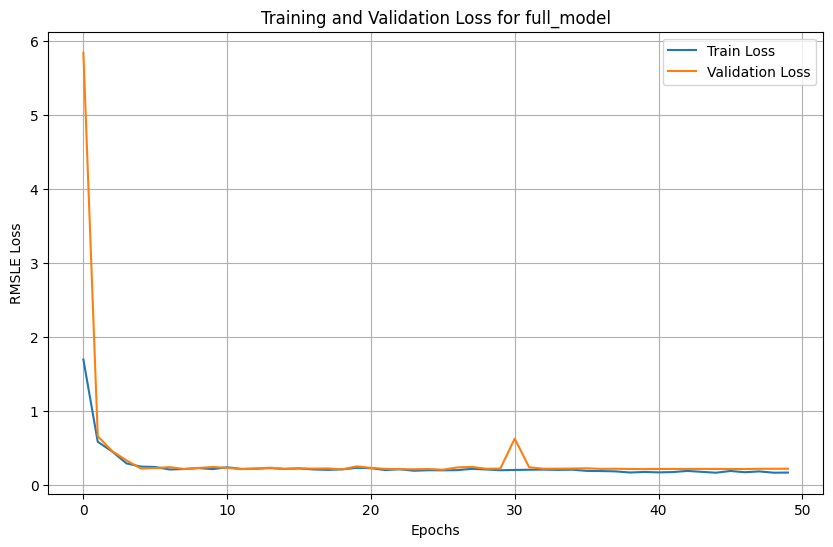

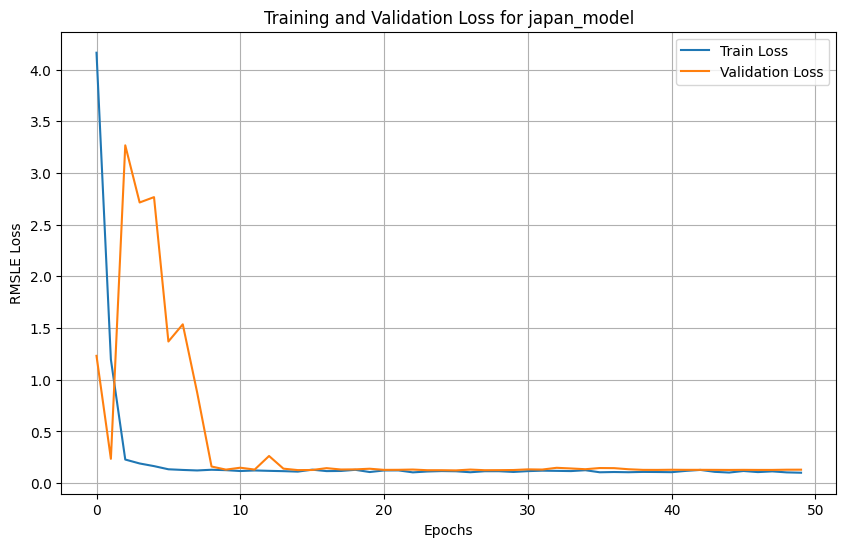

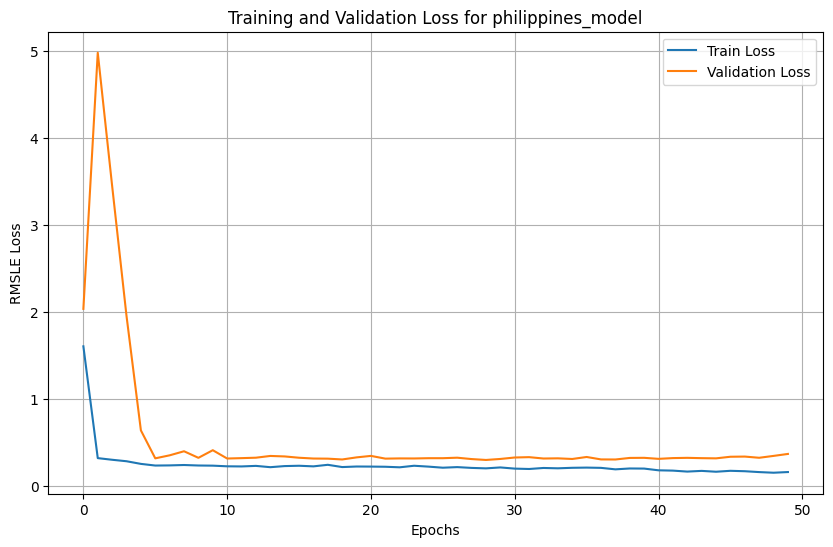

In [15]:
def plot_losses(modelName):
    checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=True)
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'Training and Validation Loss for {modelName}')
    plt.xlabel('Epochs')
    plt.ylabel('RMSLE Loss')
    plt.legend()
    plt.grid()
    plt.show()


plot_losses("full_model")
plot_losses("japan_model")
plot_losses("philippines_model")

### Submission
Make a submission file for each of the model solutions

In [ ]:
submissionPath = Path("..") / "Submissions"
split_submission = pd.DataFrame()
full_submission = pd.DataFrame()
data_ids = []
split_predictions = []
full_predictions = []

#Converting data to the dataset the model will accept
eval_dataset = MultiModalDataset(eval_df, numeric_cols, categorical_cols, img_col, target_col, id_col)

#Loading each model
full_checkpoint = torch.load(ModelPath / "full_model.pth", weights_only=True)
full_model = initialize_model(full_df, full_df)
full_model.load_state_dict(full_checkpoint['model'])
full_model.eval()

philippines_checkpoint = torch.load(ModelPath / "philippines_model.pth", weights_only=True)
philippines_model = initialize_model(philippines_df, full_df)
philippines_model.load_state_dict(philippines_checkpoint['model'])
philippines_model.eval()

japan_checkpoint = torch.load(ModelPath / "japan_model.pth", weights_only=True)
japan_model = initialize_model(japan_df, full_df)
japan_model.load_state_dict(japan_checkpoint['model'])
japan_model.eval()

#Preparing columns to evaluate
ph_x_num = [col for col in numeric_cols if col in philippines_df.columns]
jp_x_num = [col for col in numeric_cols if col in japan_df.columns]
ph_indices = [i for i, col in enumerate(numeric_cols) if col in philippines_df.columns]
jp_indices = [i for i, col in enumerate(numeric_cols) if col in japan_df.columns]

#Predicting
for data in eval_dataset:
    data_id = data["id"]
    data_ids.append(data["id"])

    country = data["numeric"][numeric_cols.index("country")].item()

    with torch.no_grad():

        x_num_full = data["numeric"].to(device).unsqueeze(0)
        x_cat = data["categorical"].to(device).unsqueeze(0)
        img_s = data["sentinel_img"].to(device).unsqueeze(0)
        img_v = data["viirs_img"].to(device).unsqueeze(0)

        if country == 0: #Philippines
            x_num = x_num_full[:, ph_indices]
            pred = philippines_model(x_num, x_cat, img_s, img_v)
        else: #Japan
            x_num = x_num_full[:, jp_indices]
            pred = japan_model(x_num, x_cat, img_s, img_v)

        full_pred = full_model(x_num_full, x_cat, img_s, img_v)
        
    full_predictions.append(full_pred.item())
    split_predictions.append(pred.item())

#Creating submission files
split_submission["data_id"] = data_ids
split_submission["construction_cost_per_m2_usd"] = split_predictions
split_submission.to_csv(submissionPath / "split_submission.csv", index=False)

full_submission["data_id"] = data_ids
full_submission["construction_cost_per_m2_usd"] = full_predictions
full_submission.to_csv(submissionPath / "full_submission.csv", index=False)